In [9]:
# IMPORTATION DES DIFFERENTES LIBRAIRIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix
)

In [10]:
# CHARGEMENT DU DATASET
df = pd.read_csv(r"E:\Localhost_Academy (IA et Data Analysis)\eval_mi_parcours\data\train_clean.csv", low_memory=False)

In [11]:
# VERIFICATION DES TYPES AVANT SEPARATION
print(df.dtypes)
print()
print("Colonnes de type object restantes :", df.select_dtypes(include='object').columns.tolist())

Age                           int64
SSN                          object
Occupation                   object
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts           float64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                   int64
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age            int64
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour            object
Monthly_Balance             float64
Credit_Score                 object
dtype: object

Colonnes de type object restantes : ['SSN', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score']


In [12]:
# CHANGEMENT DES COLONNES DE TYPE OBJECT EN TYPE CATEGORY

colonnes_cat = [
    'SSN',
    'Occupation',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Payment_Behaviour'
]

# filtre pour ne garder que les colonnes presentes dans le DataFrame
colonnes_cat = [col for col in colonnes_cat if col in df.columns]
df[colonnes_cat] = df[colonnes_cat].astype('category')

print("Colonnes converties en category :", colonnes_cat)

Colonnes converties en category : ['SSN', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


In [13]:
# VERIFICATION DES VALEURS UNIQUES DE LA CIBLE
print("Valeurs uniques de Credit_Score :", df['Credit_Score'].unique())

Valeurs uniques de Credit_Score : ['Good' 'Standard' 'Poor']


In [14]:
# ENCODER Y AVEC LABEL ENCODING
df['Credit_Score'] = df['Credit_Score'].map({'Good': 0, 'Poor': 1, 'Standard': 2})

print("Distribution de Credit_Score apres encodage :")
print(df['Credit_Score'].value_counts())

Distribution de Credit_Score apres encodage :
Credit_Score
2    53174
1    28998
0    17828
Name: count, dtype: int64


In [15]:
# SEPARATION DES FEATURES ET DE LA TARGET
# On exclut SSN (identifiant sans valeur predictive) et les colonnes non numeriques
colonnes_a_exclure = ['SSN', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
colonnes_a_exclure = [col for col in colonnes_a_exclure if col in df.columns]

y = df['Credit_Score']
X = df.drop(columns=['Credit_Score'] + colonnes_a_exclure)

# assure que X ne contient que des colonnes numeriques
X = X.select_dtypes(include=[np.number])

print("Shape X :", X.shape)
print("Shape y :", y.shape)
print("\nTypes de X :")
print(X.dtypes)

Shape X : (100000, 17)
Shape y : (100000,)

Types de X :
Age                           int64
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts           float64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                   int64
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age            int64
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Monthly_Balance             float64
dtype: object


In [16]:
# SEPARATION EN TRAIN ET TEST (80% / 20%) AVEC random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test  :", X_test.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test  :", y_test.shape)

Dimensions de X_train : (80000, 17)
Dimensions de X_test  : (20000, 17)
Dimensions de y_train : (80000,)
Dimensions de y_test  : (20000,)


In [17]:
# NORMALISATION DES FEATURES NUMERIQUES AVEC StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Normalisation terminee.")
print("Moyenne X_train_scaled (doit etre ~0) :", X_train_scaled.mean(axis=0).round(4))

Normalisation terminee.
Moyenne X_train_scaled (doit etre ~0) : [ 0. -0. -0.  0.  0. -0.  0.  0.  0.  0.  0. -0. -0. -0. -0.  0.  0.]


In [18]:
# ENTRAINEMENT DU MODELE : LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Modele entraine avec succes.")

Modele entraine avec succes.


In [19]:
# EVALUATION SUR X_TEST

y_pred = model.predict(X_test_scaled)

acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print()
print("Rapport de classification complet :")
print(classification_report(y_test, y_pred,
                             target_names=['Good (0)', 'Poor (1)', 'Standard (2)'],
                             zero_division=0))

Accuracy  : 0.6009
Precision : 0.5977
Recall    : 0.6009
F1-Score  : 0.5800

Rapport de classification complet :
              precision    recall  f1-score   support

    Good (0)       0.51      0.28      0.36      3527
    Poor (1)       0.64      0.43      0.52      5874
Standard (2)       0.60      0.80      0.69     10599

    accuracy                           0.60     20000
   macro avg       0.58      0.50      0.52     20000
weighted avg       0.60      0.60      0.58     20000



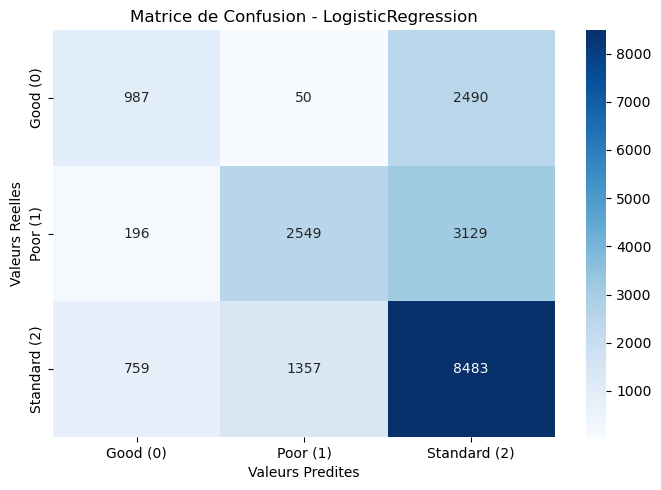

Matrice de confusion sauvegardee dans figures/confusion_matrix.png


In [20]:
# MATRICE DE CONFUSION

os.makedirs('figures', exist_ok=True)

cm = confusion_matrix(y_test, y_pred)
labels = ['Good (0)', 'Poor (1)', 'Standard (2)']

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Matrice de Confusion - LogisticRegression')
plt.xlabel('Valeurs Predites')
plt.ylabel('Valeurs Reelles')
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Matrice de confusion sauvegardee dans figures/confusion_matrix.png")

In [21]:
# SAUVEGARDE DU MODELE AVEC JOBLIB

os.makedirs('model', exist_ok=True)
joblib.dump(model, 'model/credit_model.joblib')

print("Modele sauvegarde dans model/credit_model.joblib")

Modele sauvegarde dans model/credit_model.joblib
